# Parte 2 - Explorando BERT e Embeddings Contextuais
## Objetivo: Entender como o BERT gera embeddings diferentes para a mesma palavra em diferentes contextos.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
print("Setup completo!")

Setup completo!


In [5]:
# Questão 2.1. Carregar o BERT e Tokenizador
from transformers import AutoTokenizer, AutoModel
import torch

print("="*60)
print("CARREGANDO BERT (pode levar alguns minutos)...")
print("="*60)

# [TODO 2.1.1] Carregue o modelo BERT multilíngue
# Dica: use "bert-base-multilingual-cased"
model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

print(f"Modelo '{model_name}' carregado!")
print(f"Tamanho do vocabulário: {tokenizer.vocab_size}")
print(f"Dimensão dos embeddings: {model.config.hidden_size}")

CARREGANDO BERT (pode levar alguns minutos)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8902.35it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo 'bert-base-multilingual-cased' carregado!
Tamanho do vocabulário: 119547
Dimensão dos embeddings: 768


In [14]:
# Questão 2.2. Palavras Polissémicas
# Vamos explorar a palavra "banco" em diferentes contextos

sentences = [
    "Fui ao banco depositar dinheiro.",  # banco financeiro
    "Sentei no banco da praça para descansar.",  # banco (assento)
    "O programador consultou o banco de dados.",  # banco de dados
    "As crianças brincaram no banco de areia.",  # banco de areia
]

print("\n" + "="*60)
print("ANÁLISE DA PALAVRA 'BANCO' EM DIFERENTES CONTEXTOS")
print("="*60)

# [TODO 2.2.1] Complete a função para extrair embedding de uma palavra específica
def get_word_embedding(sentence, word, tokenizer, model):
    """
    Extrai o embedding de uma palavra específica numa frase
    """
    
    # Tokenizar a frase
    inputs = tokenizer(sentence, return_tensors="pt", padding=True, truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Obter tokens
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    
    # [TODO] Encontrar a posição da palavra (ignorando [CLS] e [SEP])
    word_positions = []
    acc = ""
    start = None
    for i, token in enumerate(tokens):
        if token in ("[CLS]", "[SEP]"):
            continue
        if token.startswith("##"):
            acc += token[2:]
        else:
            acc = token
            start = i
        if acc == word and start is not None:
            word_positions.append(start)
            break
        
    if not word_positions:
        print(f" Palavra '{word}' não encontrada na frase")
        return None, tokens

    # [TODO] Pegar o embedding do primeiro token da palavra
    # Dica: outputs.last_hidden_state[0, posição].numpy()
    pos = word_positions[0]
    word_embedding = outputs.last_hidden_state[0, pos].detach().cpu().numpy()

    return word_embedding, tokens
    
# Armazenar embeddings (e rótulos alinhados — necessário para a secção 2.3)
banco_embeddings = []
banco_context_labels = []
context_label_by_sentence = [
    "Frase 1 (financeiro)",
    "Frase 2 (assento)",
    "Frase 3 (dados)",
    "Frase 4 (areia)",
]

for i, sentence in enumerate(sentences):
    print(f"\n Frase {i+1}: {sentence}")

    # [TODO] Chame a função get_word_embedding para a palavra "banco"
    embedding, tokens = get_word_embedding(sentence, "banco", tokenizer, model)

    if embedding is not None:
        banco_embeddings.append(embedding)
        lbl = context_label_by_sentence[i] if i < len(context_label_by_sentence) else f"Frase {i + 1}"
        banco_context_labels.append(lbl)
        print(f" Tokens: {tokens}")
        print(f" Embedding shape: {embedding.shape}")
        print(f" Primeiros 10 valores: {embedding[:10].round(3)}")

print(f"\n→ Total de embeddings de 'banco' guardados: {len(banco_embeddings)} (esperado: {len(sentences)})")


ANÁLISE DA PALAVRA 'BANCO' EM DIFERENTES CONTEXTOS

 Frase 1: Fui ao banco depositar dinheiro.
 Tokens: ['[CLS]', 'Fu', '##i', 'ao', 'banco', 'de', '##posit', '##ar', 'dinheiro', '.', '[SEP]']
 Embedding shape: (768,)
 Primeiros 10 valores: [ 0.309 -0.594  0.681  0.691 -0.144  0.621 -0.102  0.138 -0.025  0.066]

 Frase 2: Sentei no banco da praça para descansar.
 Tokens: ['[CLS]', 'Sent', '##ei', 'no', 'banco', 'da', 'pra', '##ça', 'para', 'des', '##cans', '##ar', '.', '[SEP]']
 Embedding shape: (768,)
 Primeiros 10 valores: [ 0.026 -0.266  0.353  0.313  0.215  0.762 -0.526  0.032 -0.276  0.013]

 Frase 3: O programador consultou o banco de dados.
 Tokens: ['[CLS]', 'O', 'programa', '##dor', 'consul', '##tou', 'o', 'banco', 'de', 'dados', '.', '[SEP]']
 Embedding shape: (768,)
 Primeiros 10 valores: [-0.049 -0.361  0.425  1.155 -0.025  0.815 -0.324 -0.156 -0.442 -0.605]

 Frase 4: As crianças brincaram no banco de areia.
 Tokens: ['[CLS]', 'As', 'crianças', 'br', '##in', '##cara', '##

Questão 2.2.2. Quantos tokens o BERT usou para representar a palavra "banco" na primeira frase?

• A) 1 token

• B) 2 tokens

• C) 3 tokens

• D) Depende do contexto

Resposta: A.


MATRIZ DE SIMILARIDADE - EMBEDDINGS DE 'BANCO'


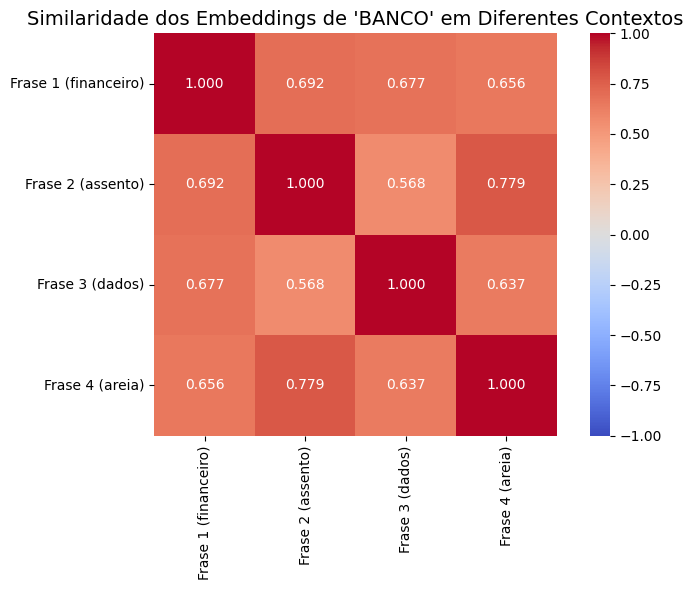


📊 Análise das similaridades:
 Frase 1 (financeiro) ↔ Frase 2 (assento): 0.6915
 Frase 1 (financeiro) ↔ Frase 3 (dados): 0.6766
 Frase 1 (financeiro) ↔ Frase 4 (areia): 0.6559
 Frase 2 (assento) ↔ Frase 3 (dados): 0.5685
 Frase 2 (assento) ↔ Frase 4 (areia): 0.7794
 Frase 3 (dados) ↔ Frase 4 (areia): 0.6375


In [15]:
# Questão 2.3. Comparar os Embeddings
# [TODO 2.3.1] Calcular similaridade entre os embeddings de "banco"
# Importante: corre primeiro a célula 2.2 (acima) para preencher banco_embeddings.

n = len(banco_embeddings)
if n < 2:
    print(
        f"Só há {n} embedding(s)."
    )
else:
    print("\n" + "="*60)
    print("MATRIZ DE SIMILARIDADE - EMBEDDINGS DE 'BANCO'")
    print("="*60)

    similarity_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            # [TODO] Calcular similaridade de cosseno entre banco_embeddings[i] e banco_embeddings[j]
            similarity_matrix[i, j] = cosine_similarity(
                banco_embeddings[i].reshape(1, -1),
                banco_embeddings[j].reshape(1, -1),
            )[0, 0]

    labels = (
        banco_context_labels
        if len(banco_context_labels) == n
        else [f"Contexto {k + 1}" for k in range(n)]
    )

    df_sim = pd.DataFrame(similarity_matrix, index=labels, columns=labels)

    # [TODO] Criar heatmap
    plt.figure(figsize=(max(8, n * 2), max(6, n * 1.5)))

    sns.heatmap(
        df_sim,
        annot=True,
        fmt=".3f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        square=True,
    )
    plt.title("Similaridade dos Embeddings de 'BANCO' em Diferentes Contextos", fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\n📊 Análise das similaridades:")

    for i in range(n):
        for j in range(i + 1, n):
            print(f" {labels[i]} ↔ {labels[j]}: {similarity_matrix[i, j]:.4f}")